In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
data = pd.read_csv("imdb-videogames.csv")

In [7]:
data.head()

,Unnamed: 0,name,url,year,certificate,rating,votes,plot,Action,Adventure,Comedy,Crime,Family,Fantasy,Mystery,Sci-Fi,Thriller
0,0,Spider-Man,https://www.imdb.com/title/tt5807780/?ref_=adv...,2018.0,T,9.2,"20,759","When a new villain threatens New York City, Pe...",True,True,False,False,False,True,False,False,False
1,1,Red Dead Redemption II,https://www.imdb.com/title/tt6161168/?ref_=adv...,2018.0,M,9.7,"35,703",Amidst the decline of the Wild West at the tur...,True,True,False,True,False,False,False,False,False
2,2,Grand Theft Auto V,https://www.imdb.com/title/tt2103188/?ref_=adv...,2013.0,M,9.5,"59,986",Three very different criminals team up for a s...,True,False,False,True,False,False,False,False,False
3,3,God of War,https://www.imdb.com/title/tt5838588/?ref_=adv...,2018.0,M,9.6,"26,118","After wiping out the gods of Mount Olympus, Kr...",True,True,False,False,False,False,False,False,False
4,4,Uncharted 4: A Thief's End,https://www.imdb.com/title/tt3334704/?ref_=adv...,2016.0,T,9.5,"28,722",Thrown back into the dangerous underworld he'd...,True,True,False,False,False,False,False,False,False


IMDb = Internet Movie Database
Although IMDb was originally created for movies and TV shows, it also includes:

Video games

TV episodes

Series

Actors & voice actors

Production credits

In [8]:
data.shape

(20803, 17)

rows=20803
columns=17

In [9]:
data.columns.tolist()

['Unnamed: 0',
 'name',
 'url',
 'year',
 'certificate',
 'rating',
 'votes',
 'plot',
 'Action',
 'Adventure',
 'Comedy',
 'Crime',
 'Family',
 'Fantasy',
 'Mystery',
 'Sci-Fi',
 'Thriller']

data.columns → returns all column names of the DataFrame as an Index object

.tolist() → converts that Index into a normal Python list

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20803 entries, 0 to 20802
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   20803 non-null  int64  
 1   name         20803 non-null  object 
 2   url          20803 non-null  object 
 3   year         20536 non-null  float64
 4   certificate  7903 non-null   object 
 5   rating       11600 non-null  float64
 6   votes        11600 non-null  object 
 7   plot         20803 non-null  object 
 8   Action       20803 non-null  bool   
 9   Adventure    20803 non-null  bool   
 10  Comedy       20803 non-null  bool   
 11  Crime        20803 non-null  bool   
 12  Family       20803 non-null  bool   
 13  Fantasy      20803 non-null  bool   
 14  Mystery      20803 non-null  bool   
 15  Sci-Fi       20803 non-null  bool   
 16  Thriller     20803 non-null  bool   
dtypes: bool(9), float64(2), int64(1), object(5)
memory usage: 1.4+ MB


In [11]:
data.describe()

,Unnamed: 0,year,rating
count,20803.000000,20536.000000,11600.000000
mean,10401.000000,2005.568611,7.047526
std,6005.453161,11.846028,1.235204
min,0.000000,1952.000000,1.000000
25%,5200.500000,1997.000000,6.400000
50%,10401.000000,2008.000000,7.200000
75%,15601.500000,2016.000000,7.900000
max,20802.000000,2027.000000,9.700000


In [12]:
data.describe(include="all")

,Unnamed: 0,name,url,year,certificate,rating,votes,plot,Action,Adventure,Comedy,Crime,Family,Fantasy,Mystery,Sci-Fi,Thriller
count,20803.000000,20803,20803,20536.000000,7903,11600.000000,11600,20803,20803,20803,20803,20803,20803,20803,20803,20803,20803
unique,NaN,19714,20157,NaN,21,NaN,1905,11276,2,2,2,2,2,2,2,2,2
top,NaN,Spider-Man,https://www.imdb.com/title/tt5807780/?ref_=adv...,NaN,T,NaN,7,Add a Plot,True,False,False,False,False,False,False,False,False
freq,NaN,9,4,NaN,2474,NaN,318,8874,11930,10469,19020,19908,17928,16453,19618,17213,20280
mean,10401.000000,NaN,NaN,2005.568611,NaN,7.047526,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,6005.453161,NaN,NaN,11.846028,NaN,1.235204,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,NaN,NaN,1952.000000,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,5200.500000,NaN,NaN,1997.000000,NaN,6.400000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,10401.000000,NaN,NaN,2008.000000,NaN,7.200000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,15601.500000,NaN,NaN,2016.000000,NaN,7.900000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
data.isnull().sum()

Unnamed: 0         0
name               0
url                0
year             267
certificate    12900
rating          9203
votes           9203
plot               0
Action             0
Adventure          0
Comedy             0
Crime              0
Family             0
Fantasy            0
Mystery            0
Sci-Fi             0
Thriller           0
dtype: int64

1.rating missing for 9,203 rows out of 20,803, so any “top rated” analysis is really on the 11,600 rows that have ratings.

2.votes are missing for 9,203 rows out of 20,803, so any “most voted” analysis is really on the 11,600 rows that have votes.

3certificate is missing for 12,900 rows, so we better drop/ignore the column.

In [14]:
data["certificate"].value_counts()

certificate
T            2474
E            2006
M            1820
E10+          814
Unrated       241
K-A           227
Not Rated     184
AO             32
GA             26
EC             25
CE             13
12              9
MA-13           7
PG-13           7
G               4
Approved        4
MA-17           3
PG              3
TV-MA           2
TV-14           1
Passed          1
Name: count, dtype: int64

E (Everyone)
Suitable for all ages. May contain minimal cartoon/fantasy violence.

E10+ (Everyone 10+)
Ages 10 and up. Mild violence, mild language, or minimal suggestive themes.

T (Teen)
Ages 13+. Violence, mild blood, crude humor, mild language, or suggestive themes.

M (Mature)
Ages 17+. Intense violence, blood and gore, strong language, sexual content.

AO (Adults Only)
18+. Explicit sexual content or extreme violence. Very rare for mainstream games.

EC (Early Childhood)
Ages 3+. Educational content for very young children. (Very rare today.)

K-A (Kids to Adults)
Old ESRB rating (1994–1998). Later renamed to E.

12
Suitable for ages 12+. Non-realistic violence or mild bad language.

(PEGI also has 3, 7, 16, 18 — but only 12 appears in your data.)

G (General Audiences)
All ages admitted.

PG (Parental Guidance Suggested)
Some material may not be suitable for children.

PG-13
Parents strongly cautioned. Some material inappropriate under 13.

R (not in your list but common)
Restricted. Under 17 requires adult.

Approved
Old U.S. rating (1930s–1968). Pre-MPAA system.

Passed
Another old pre-1968 U.S. approval label.

TV-14
Parents strongly cautioned. May contain strong language or violence.

TV-MA
Mature audiences only (17+). Strong content.

GA
General Audience (all ages).

MA-13
Not suitable for under 13.

MA-17
Not suitable for under 17.

CE
Cinema Evaluation Board rating (general approval classification).

Unrated
No official rating assigned.

Not Rated
Similar to Unrated — no official classification.

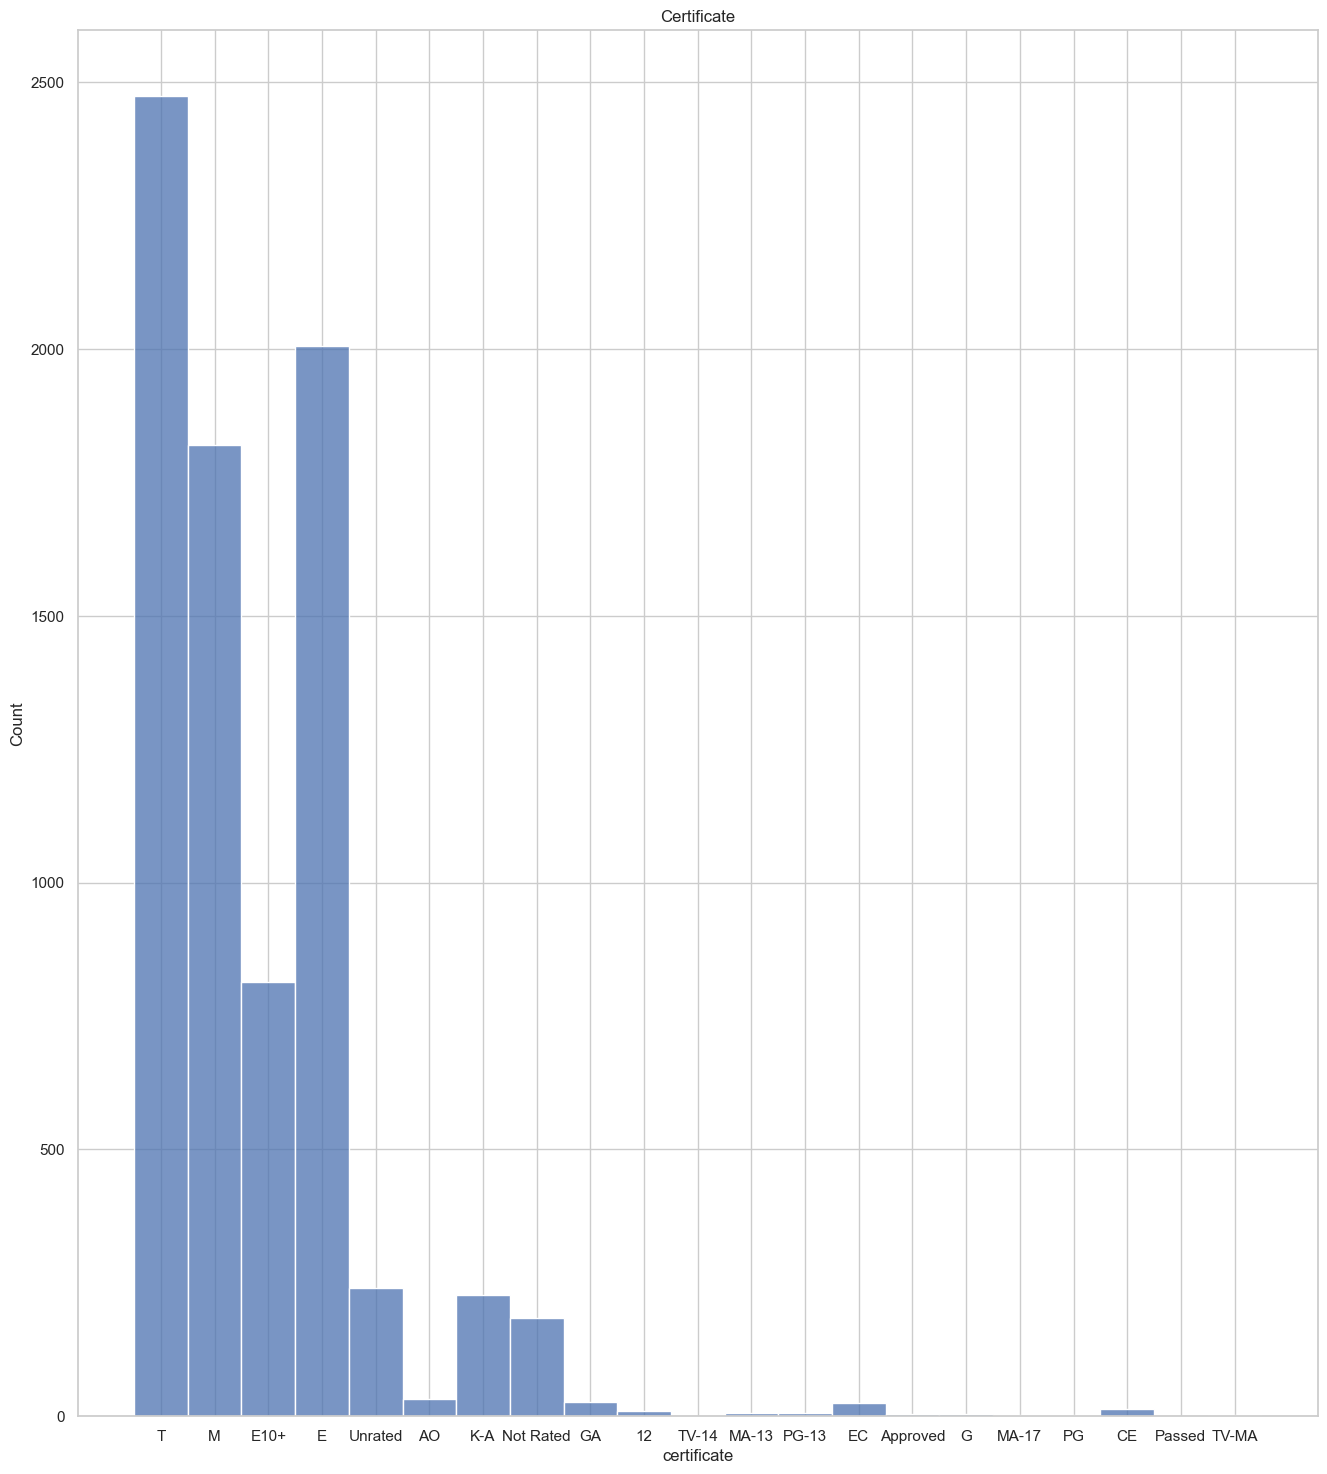

In [34]:
plt.figure(figsize=(16, 18))
sns.histplot(x='certificate', data=data)
plt.title('Certificate')
plt.show()

In [16]:
#games between 1950 to 2026
sns.set_theme(style='whitegrid')
viz_df = data.copy()
viz_df = viz_df[(viz_df['year'].notna()) & (viz_df['year'] >= 1950) & (viz_df['year'] <= 2026)]

In [17]:
viz_df

,Unnamed: 0,name,url,year,certificate,rating,votes,plot,Action,Adventure,Comedy,Crime,Family,Fantasy,Mystery,Sci-Fi,Thriller
0,0,Spider-Man,https://www.imdb.com/title/tt5807780/?ref_=adv...,2018.0,T,9.2,"20,759","When a new villain threatens New York City, Pe...",True,True,False,False,False,True,False,False,False
1,1,Red Dead Redemption II,https://www.imdb.com/title/tt6161168/?ref_=adv...,2018.0,M,9.7,"35,703",Amidst the decline of the Wild West at the tur...,True,True,False,True,False,False,False,False,False
2,2,Grand Theft Auto V,https://www.imdb.com/title/tt2103188/?ref_=adv...,2013.0,M,9.5,"59,986",Three very different criminals team up for a s...,True,False,False,True,False,False,False,False,False
3,3,God of War,https://www.imdb.com/title/tt5838588/?ref_=adv...,2018.0,M,9.6,"26,118","After wiping out the gods of Mount Olympus, Kr...",True,True,False,False,False,False,False,False,False
4,4,Uncharted 4: A Thief's End,https://www.imdb.com/title/tt3334704/?ref_=adv...,2016.0,T,9.5,"28,722",Thrown back into the dangerous underworld he'd...,True,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20798,20798,"Enjoy Your Power, Enjoy Your Choice",https://www.imdb.com/title/tt3845606/?ref_=adv...,2014.0,NaN,NaN,NaN,Add a Plot,False,False,False,False,False,False,False,False,True
20799,20799,RedSun2020,https://www.imdb.com/title/tt0790739/?ref_=adv...,2004.0,NaN,NaN,NaN,Joseph gets kidnapped and it's the player's jo...,False,False,False,False,False,False,False,False,True
20800,20800,Shutter,https://www.imdb.com/title/tt5119948/?ref_=adv...,2015.0,NaN,NaN,NaN,A tech support man who uses a drone to investi...,False,False,False,False,False,False,False,False,True
20801,20801,The Music Machine,https://www.imdb.com/title/tt5142082/?ref_=adv...,2015.0,NaN,NaN,NaN,A young teenage girl and the ghost of a dead m...,False,False,False,False,False,False,False,False,True


In [18]:
data.votes

0        20,759
1        35,703
2        59,986
3        26,118
4        28,722
          ...  
20798       NaN
20799       NaN
20800       NaN
20801       NaN
20802       NaN
Name: votes, Length: 20803, dtype: object

In [19]:
data.votes=data.votes.str.replace(',','')

In [20]:
data.votes=pd.to_numeric(data.votes)

In [21]:
print(pd.pivot_table(data=data,values='votes',index='Action',aggfunc='sum'))
print("-------------------------------------------------------")
print(pd.pivot_table(data=data,values='votes',index='Adventure',aggfunc='sum'))
print("-------------------------------------------------------")
print(pd.pivot_table(data=data,values='votes',index='Comedy',aggfunc='sum'))
print("-------------------------------------------------------")
print(pd.pivot_table(data=data,values='votes',index='Crime',aggfunc='sum'))
print("-------------------------------------------------------")


            votes
Action           
False    666090.0
True    6648860.0
-------------------------------------------------------
               votes
Adventure           
False      2059627.0
True       5255323.0
-------------------------------------------------------
            votes
Comedy           
False   6822523.0
True     492427.0
-------------------------------------------------------
           votes
Crime           
False  5956655.0
True   1358295.0
-------------------------------------------------------


In [22]:
print(pd.pivot_table(data=data,values='votes',index='Family',aggfunc='sum'))
print("-------------------------------------------------------")
print(pd.pivot_table(data=data,values='votes',index='Mystery',aggfunc='sum'))
print("-------------------------------------------------------")
print(pd.pivot_table(data=data,values='votes',index='Sci-Fi',aggfunc='sum'))
print("-------------------------------------------------------")
print(pd.pivot_table(data=data,values='votes',index='Thriller',aggfunc='sum'))
print("-------------------------------------------------------")
print(pd.pivot_table(data=data,values='votes',index='Fantasy',aggfunc='sum'))

            votes
Family           
False   6905804.0
True     409146.0
-------------------------------------------------------
             votes
Mystery           
False    6858707.0
True      456243.0
-------------------------------------------------------
            votes
Sci-Fi           
False   6245123.0
True    1069827.0
-------------------------------------------------------
              votes
Thriller           
False     6857189.0
True       457761.0
-------------------------------------------------------
             votes
Fantasy           
False    5548942.0
True     1766008.0


In [23]:
l=['Action','Adventure', 'Comedy', 'Crime', 'Family', 'Fantasy', 'Mystery','Sci-Fi', 'Thriller']
votes_by_genre=[]
for i in l:
    votes_by_genre.append(pd.pivot_table(data=data,values='votes',index=i,aggfunc='sum')['votes'][True])
df=pd.DataFrame({'genre':l,'Popularity':votes_by_genre})
df


,genre,Popularity
0,Action,6648860.0
1,Adventure,5255323.0
2,Comedy,492427.0
3,Crime,1358295.0
4,Family,409146.0
5,Fantasy,1766008.0
6,Mystery,456243.0
7,Sci-Fi,1069827.0
8,Thriller,457761.0


In [37]:
df.sort_values(by='Popularity',ascending=False)

,genre,Popularity
0,Action,6648860.0
1,Adventure,5255323.0
5,Fantasy,1766008.0
3,Crime,1358295.0
7,Sci-Fi,1069827.0
2,Comedy,492427.0
8,Thriller,457761.0
6,Mystery,456243.0
4,Family,409146.0


Genre Top by popularity = Action
Genre least by popularity = Family

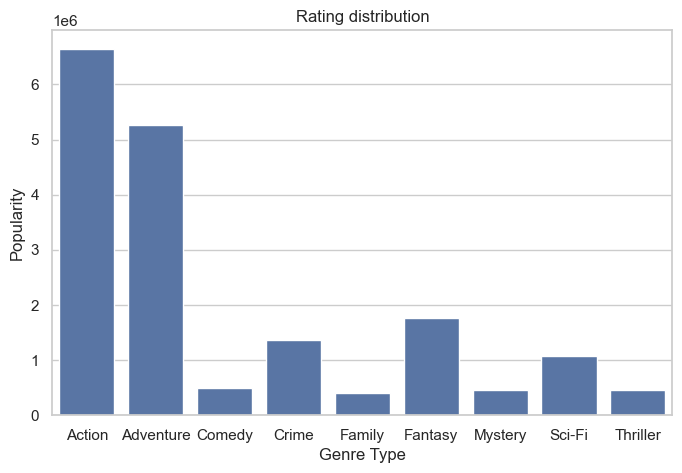

In [38]:
# 1) Genre Type by Popularity
plt.figure(figsize=(8,5))
ax = sns.barplot(x='genre', y='Popularity', data=df)
plt.title('Rating distribution')
plt.xlabel('Genre Type')
plt.ylabel('Popularity')
plt.show()

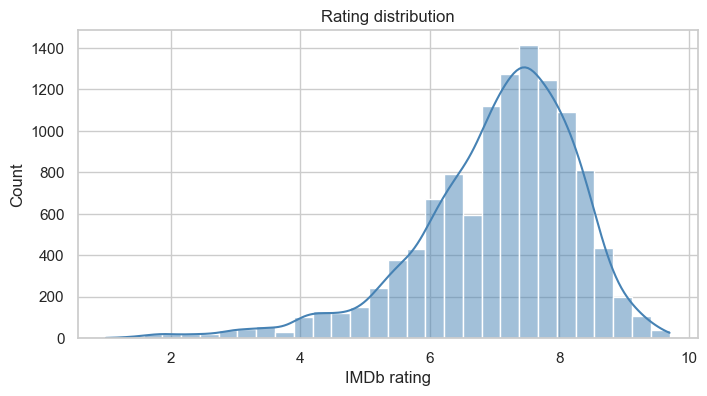

In [26]:
# 2) Rating distribution
plt.figure(figsize=(8,4))
sns.histplot(viz_df['rating'].dropna(), bins=30, kde=True, color='steelblue')
plt.title('Rating distribution')
plt.xlabel('IMDb rating')
plt.ylabel('Count')
plt.show()

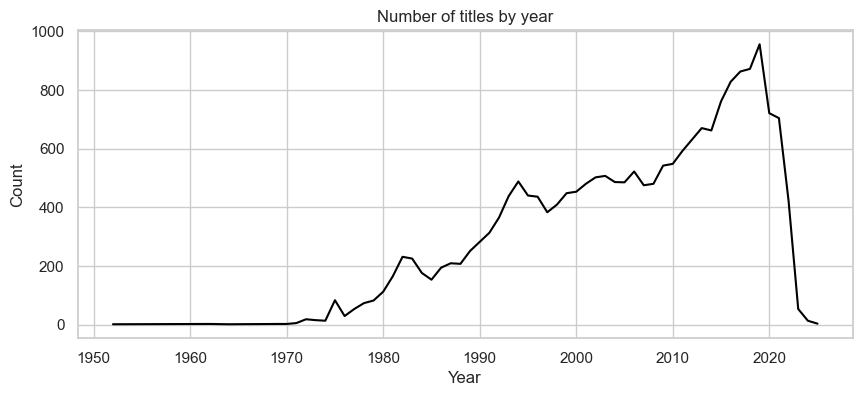

In [27]:
# 3) Titles per year
per_year = viz_df.groupby('year', as_index=False).size().sort_values('year')
plt.figure(figsize=(10,4))
sns.lineplot(data=per_year, x='year', y='size', color='black')
plt.title('Number of titles by year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()